# Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights
Objective: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

Dataset: This lab utilizes the Amazon UK product dataset which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [1]:
# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. Load dataset

df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [7]:
# 3. Basic exploration

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB


In [9]:
df.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


## Part 1: Understanding Product Categories
Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

In [11]:
# Frequency table for product categories

category_freq = df['category'].value_counts()
category_freq

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [12]:
# Top 5 most listed categories

top_5_categories = category_freq.head(5)
top_5_categories

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

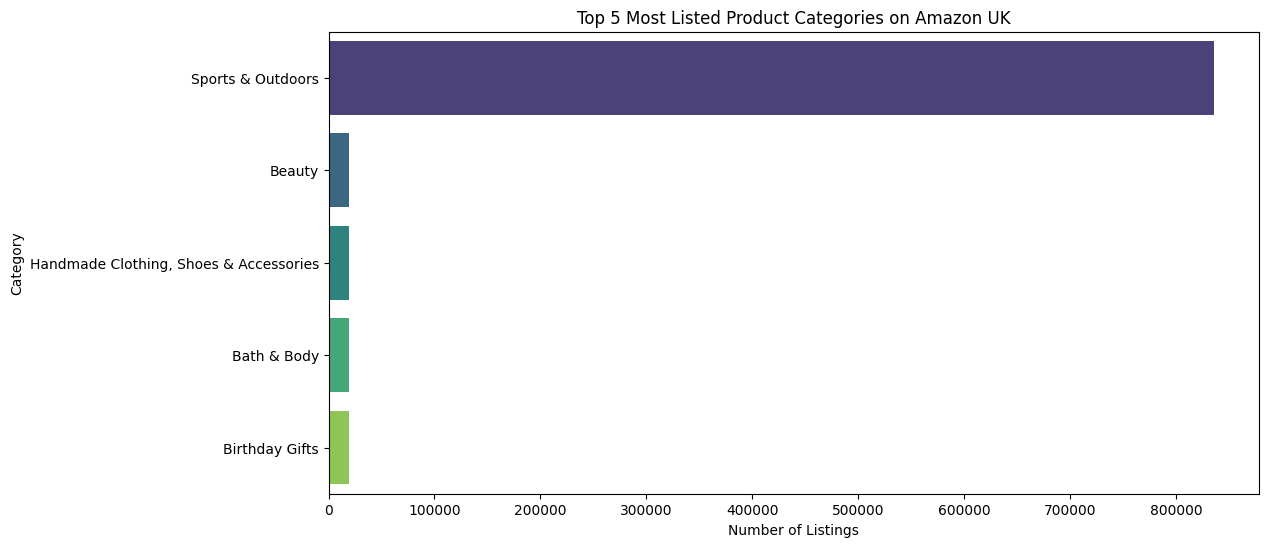

In [13]:
# Bar chart for top categories

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_5_categories.values,
    y=top_5_categories.index,
    hue=top_5_categories.index,
    palette="viridis",
    legend=False
)

plt.title("Top 5 Most Listed Product Categories on Amazon UK")
plt.xlabel("Number of Listings")
plt.ylabel("Category")
plt.show()

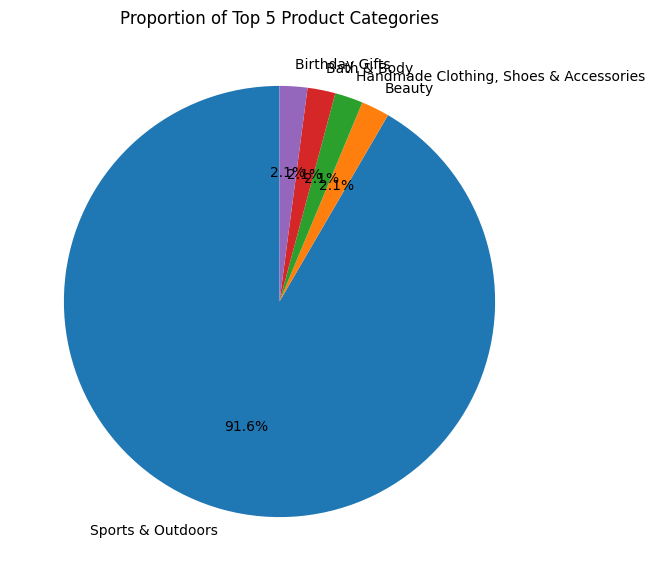

In [16]:
# pie chart for a subset of top categories 

plt.figure(figsize=(7,7))
top_5_categories.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proportion of Top 5 Product Categories")
plt.ylabel("")
plt.show()

Sports & Outdoors overwhelmingly dominates the publications, representing approximately 91.6% of the categories in the analyzed subset.

### Business Q1 answer:

The analysis shows that product listings on Amazon UK are highly concentrated in a few categories, with Sports & Outdoors overwhelmingly dominating the dataset.

A high number of listings in a category may indicate strong customer demand, but it can also suggest intense market competition. 

For sellers, entering highly saturated categories may require stronger differentiation strategies, such as competitive pricing, better branding, optimized product descriptions, and stronger customer reviews to stand out from competitors.

## Part 2: Delving into Product Pricing
Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

In [17]:
# Check price column

df['price'].describe()

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64

In [18]:
pd.options.display.float_format = '{:,.2f}'.format

In [19]:
df['price'].describe()

count   2,443,651.00
mean           89.24
std           345.61
min             0.00
25%             9.99
50%            19.09
75%            45.99
max       100,000.00
Name: price, dtype: float64

In [21]:
# Measures of centrality

price_mean = df['price'].mean()
price_median = df['price'].median()
price_mode = df['price'].mode()[0]

print(f"Mean price: £{price_mean:.2f}")
print(f"Median price: £{price_median:.2f}")
print(f"Mode price: £{price_mode:.2f}")

Mean price: £89.24
Median price: £19.09
Mode price: £9.99


The average product price on Amazon UK is £89.24, while the median price is significantly lower at £19.09.

This suggests that the price distribution is right-skewed, meaning that most products are relatively affordable, while a smaller number of very expensive products increase the overall average price.

The most common price point is £9.99, which may reflect common psychological pricing strategies used by sellers.

In [22]:
# Measures of dispersion

price_variance = df['price'].var()
price_std = df['price'].std()

price_range = df['price'].max() - df['price'].min()

price_iqr = (
    df['price'].quantile(0.75)
    - df['price'].quantile(0.25)
)

print(f"Variance: {price_variance:.2f}")
print(f"Standard deviation: {price_std:.2f}")
print(f"Range: {price_range:.2f}")
print(f"IQR: {price_iqr:.2f}")

Variance: 119445.49
Standard deviation: 345.61
Range: 100000.00
IQR: 36.00


Product prices show a very large spread, indicating high variability across the marketplace.

The large standard deviation and range suggest that Amazon UK includes products from many different price segments, ranging from very low-cost items to premium or luxury products.

This wide dispersion highlights the diversity of the marketplace and suggests that pricing strategies vary significantly depending on product category and positioning.

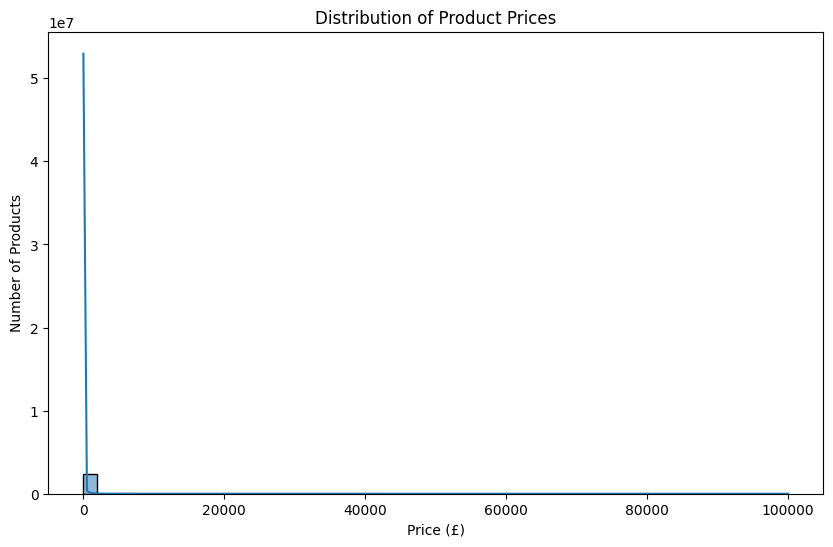

In [43]:
# Visualizations

plt.figure(figsize=(10,6))

sns.histplot(
    df['price'],
    bins=50,
    kde=True
)

plt.title("Distribution of Product Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Products")

plt.show()

In [24]:
# Remove extreme outliers visually using the 95th percentile

price_limit = df['price'].quantile(0.95)

filtered_prices = df[df['price'] <= price_limit]

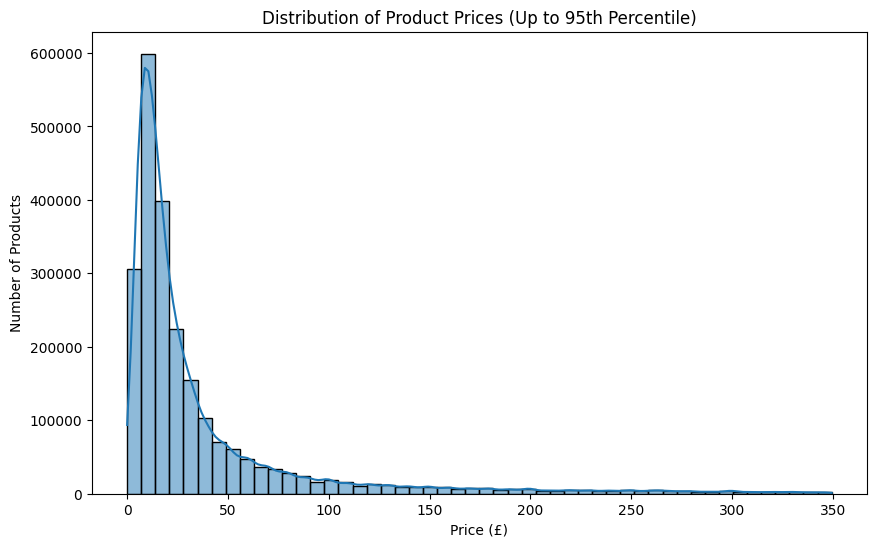

In [44]:
# histogram to visualize the distribution of product prices

plt.figure(figsize=(10,6))

sns.histplot(
    filtered_prices['price'],
    bins=50,
    kde=True
)

plt.title("Distribution of Product Prices (Up to 95th Percentile)")
plt.xlabel("Price (£)")
plt.ylabel("Number of Products")

plt.show()

After removing extreme outliers from the visualization, it becomes clear that most Amazon UK products are concentrated within lower price ranges.

This suggests that the marketplace is heavily populated by affordable consumer products, while premium-priced items represent a much smaller portion of listings.

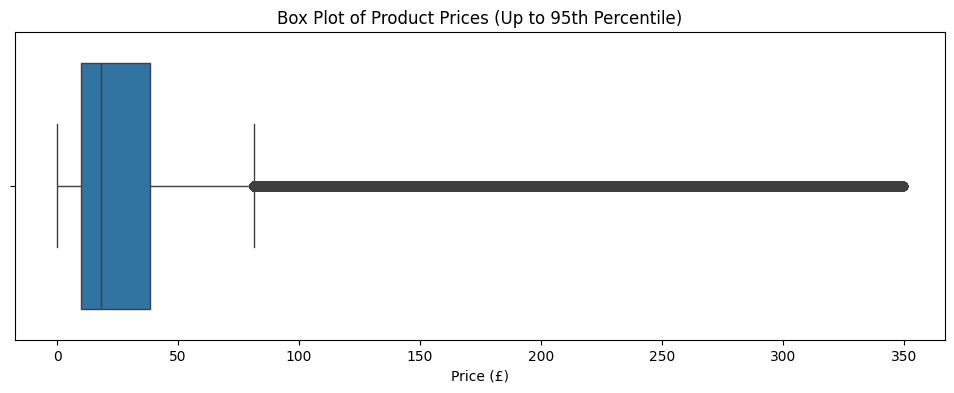

In [45]:
#  box plot to showcase the spread and potential outliers in product pricing
    
plt.figure(figsize=(12,4))

sns.boxplot(x=filtered_prices['price'])

plt.title("Box Plot of Product Prices (Up to 95th Percentile)")
plt.xlabel("Price (£)")

plt.show()

The box plot reveals the presence of numerous high-price outliers in the dataset.

Most products are concentrated within a relatively low price range, while a small number of products are priced significantly higher than the rest.

These outliers strongly influence the mean price and contribute to the right-skewed distribution observed earlier.

### Business Q2 answer:

The analysis shows that Amazon UK product prices are heavily right-skewed, with most products concentrated in lower price ranges while a smaller number of premium products significantly increase the average price.

The median price (£19.09) is substantially lower than the mean price (£89.24), indicating the presence of high-price outliers across the marketplace.

This suggests that Amazon UK supports a wide variety of pricing strategies, ranging from low-cost consumer goods to premium and luxury products. For businesses, understanding the dominant price ranges within their category may be essential for competitive positioning and pricing optimization.

## Part 3: Unpacking Product Ratings
Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

In [27]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='str')

In [28]:
df['stars'].describe()

count   2,443,651.00
mean            2.15
std             2.19
min             0.00
25%             0.00
50%             0.00
75%             4.40
max             5.00
Name: stars, dtype: float64

In [29]:
df['reviews'].describe()

count   2,443,651.00
mean          480.63
std         5,944.12
min             0.00
25%             0.00
50%             0.00
75%            59.00
max     1,356,658.00
Name: reviews, dtype: float64

In [30]:
df['boughtInLastMonth'].describe()

count   2,443,651.00
mean           25.90
std           240.48
min             0.00
25%             0.00
50%             0.00
75%             0.00
max        50,000.00
Name: boughtInLastMonth, dtype: float64

In [31]:
df['isBestSeller'].describe()

count     2443651
unique          2
top         False
freq      2435671
Name: isBestSeller, dtype: object

In [36]:
# Filter products with valid ratings 

ratings_df = df[df['stars'] > 0]
ratings_df['stars'].describe()

count   1,218,010.00
mean            4.32
std             0.56
min             1.00
25%             4.10
50%             4.40
75%             4.60
max             5.00
Name: stars, dtype: float64

A large number of products in the dataset have a rating value of 0, which likely represents products without customer reviews rather than poorly rated products.

To better understand actual customer feedback patterns, the analysis focuses on products with ratings greater than zero.

In [37]:
# Measures of centrality 

rating_mean = ratings_df['stars'].mean()
rating_median = ratings_df['stars'].median()
rating_mode = ratings_df['stars'].mode()[0]

print(f"Mean rating: {rating_mean:.2f}")
print(f"Median rating: {rating_median:.2f}")
print(f"Mode rating: {rating_mode:.2f}")

Mean rating: 4.32
Median rating: 4.40
Mode rating: 4.50


Products on Amazon UK generally receive high ratings, with most ratings concentrated around 4 to 5 stars.

This suggests that customer feedback tends to be positive overall, which is common in large e-commerce marketplaces where highly rated products gain more visibility and sales traction.

In [38]:
# Measures of dispersion

rating_variance = ratings_df['stars'].var()
rating_std = ratings_df['stars'].std()

rating_iqr = (
    ratings_df['stars'].quantile(0.75)
    - ratings_df['stars'].quantile(0.25)
)

print(f"Variance: {rating_variance:.2f}")
print(f"Standard deviation: {rating_std:.2f}")
print(f"IQR: {rating_iqr:.2f}")

Variance: 0.31
Standard deviation: 0.56
IQR: 0.50


In [47]:
# # Shape of the distribution

rating_skewness = ratings_df['stars'].skew()
rating_kurtosis = ratings_df['stars'].kurt()

print(f"Skewness: {rating_skewness:.2f}")
print(f"Kurtosis: {rating_kurtosis:.2f}")

Skewness: -2.38
Kurtosis: 9.78


The rating distribution is strongly negatively skewed, indicating that most products tend to receive high ratings rather than low ones.

Additionally, the high kurtosis value suggests that ratings are heavily concentrated around certain values (mainly between 4 and 5 stars), while still containing some extreme observations.

This pattern is common in large e-commerce platforms, where highly rated products gain more visibility and customer trust.

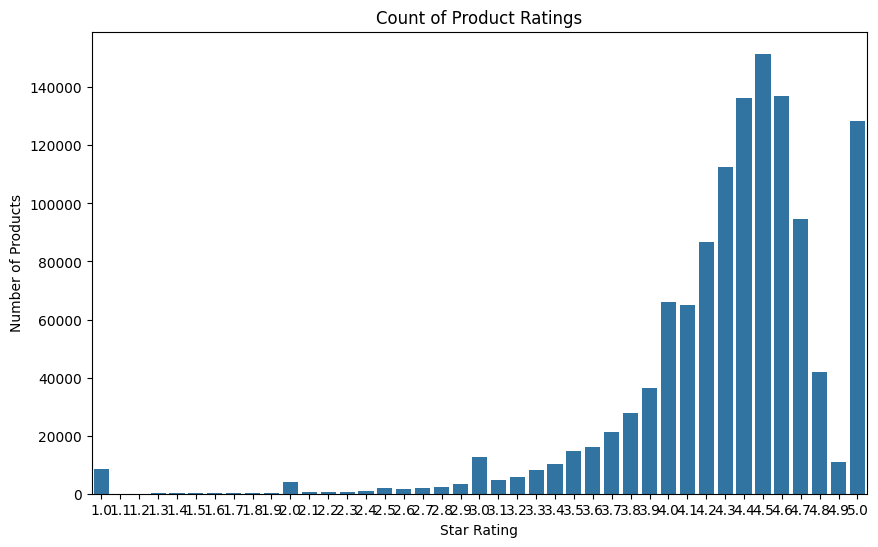

In [49]:
# A histogram plot to visualize the distribution of product ratings. Is there a specific rating that is more common?

plt.figure(figsize=(10,6))

sns.countplot(
    x=ratings_df['stars']
)

plt.title("Count of Product Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Products")

plt.show()

The histogram shows that product ratings are heavily concentrated between 4 and 5 stars, with ratings around 4.5 being the most common.

Low ratings are relatively rare, reinforcing the earlier observation that customer feedback on Amazon UK is generally very positive.

The distribution is negatively skewed, meaning that higher ratings occur much more frequently than lower ratings.

### Business Q3 answer:

Customer ratings on Amazon UK are generally very positive, with most rated products concentrated between 4 and 5 stars.

After excluding products without reviews, the analysis revealed a strong negative skewness, meaning that high ratings occur much more frequently than low ratings.

The relatively low standard deviation indicates that ratings are fairly consistent across products. This suggests that maintaining high customer satisfaction is essential for visibility and competitiveness within the Amazon marketplace.

# Final Conclusion

This exploratory data analysis provided valuable insights into product listings on Amazon UK.

The analysis revealed that product categories are highly concentrated, with Sports & Outdoors dominating the dataset. Product pricing showed strong variability, with most products positioned within affordable price ranges while a smaller number of premium products created significant price outliers.

Customer ratings were generally very positive, with most reviewed products receiving ratings between 4 and 5 stars. This suggests that customer satisfaction and strong product reviews play a major role in marketplace competitiveness.

Overall, the findings highlight the importance of category positioning, pricing strategy, and customer feedback management for sellers operating within large e-commerce platforms such as Amazon UK.